In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")



In [13]:
# 1. Generate Synthetic Dataset 

N = 600

study_hours   = np.random.uniform(1, 10, N).round(1)
attendance    = np.random.uniform(40, 100, N).round(1)   # % attendance
assignments   = np.random.randint(0, 11, N)               # out of 10
sleep_hours   = np.random.uniform(4, 9, N).round(1)
prev_score    = np.random.uniform(30, 95, N).round(1)     # previous exam score

# Final score formula with noise
final_score = (
    6.5 * study_hours
    + 0.3 * attendance
    + 3.0 * assignments
    + 1.5 * sleep_hours
    + 0.25 * prev_score
    + np.random.normal(0, 5, N)
)
final_score = np.clip(final_score, 20, 100).round(1)

df = pd.DataFrame({
    "study_hours":  study_hours,
    "attendance":   attendance,
    "assignments":  assignments,
    "sleep_hours":  sleep_hours,
    "prev_score":   prev_score,
    "final_score":  final_score
})

print("=" * 55)
print("  PROJECT 2: Student Score Prediction")
print("=" * 55)



  PROJECT 2: Student Score Prediction


In [14]:
#  2. Explore the Data 
print("\n[1] Dataset Shape:", df.shape)
print("\n[2] Summary Statistics:")
print(df.describe().round(2))




[1] Dataset Shape: (600, 6)

[2] Summary Statistics:
       study_hours  attendance  assignments  sleep_hours  prev_score  \
count       600.00      600.00       600.00       600.00      600.00   
mean          5.53       69.72         4.90         6.51       62.10   
std           2.69       17.46         3.13         1.45       18.90   
min           1.00       40.30         0.00         4.00       30.00   
25%           3.20       53.98         2.00         5.20       47.38   
50%           5.65       70.00         5.00         6.55       61.65   
75%           7.90       84.90         8.00         7.80       78.38   
max          10.00       99.90        10.00         9.00       94.90   

       final_score  
count       600.00  
mean         89.60  
std          13.65  
min          44.60  
25%          81.80  
50%          97.70  
75%         100.00  
max         100.00  


In [15]:
#  3. Correlation Analysis 
print("\n[3] Correlation with final_score:")
print(df.corr()["final_score"].sort_values(ascending=False).round(3))




[3] Correlation with final_score:
final_score    1.000
study_hours    0.720
assignments    0.379
attendance     0.228
prev_score     0.210
sleep_hours    0.026
Name: final_score, dtype: float64


In [16]:
#  4. Train / Test Split 
features = ["study_hours", "attendance", "assignments", "sleep_hours", "prev_score"]
X = df[features]
y = df["final_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n[4] Train size: {len(X_train)} | Test size: {len(X_test)}")




[4] Train size: 480 | Test size: 120


In [17]:
#  5. Scale Features 
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)



In [18]:
#  6. Train Linear Regression 
model = LinearRegression()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)



In [19]:
#  7. Evaluate 
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n[5] Model Performance:")
print(f"    R² Score  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"    MAE       : {mae:.2f}")
print(f"    RMSE      : {rmse:.2f}")




[5] Model Performance:
    R² Score  : 0.7770  (77.7% variance explained)
    MAE       : 5.34
    RMSE      : 6.68


In [20]:
#  8. Feature Importance 
coef_df = pd.DataFrame({
    "Feature":     features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)
print("\n[6] Feature Coefficients (scaled):")
print(coef_df.to_string(index=False))




[6] Feature Coefficients (scaled):
    Feature  Coefficient
study_hours     9.626770
assignments     5.144670
 attendance     3.252186
 prev_score     2.905097
sleep_hours     1.132617


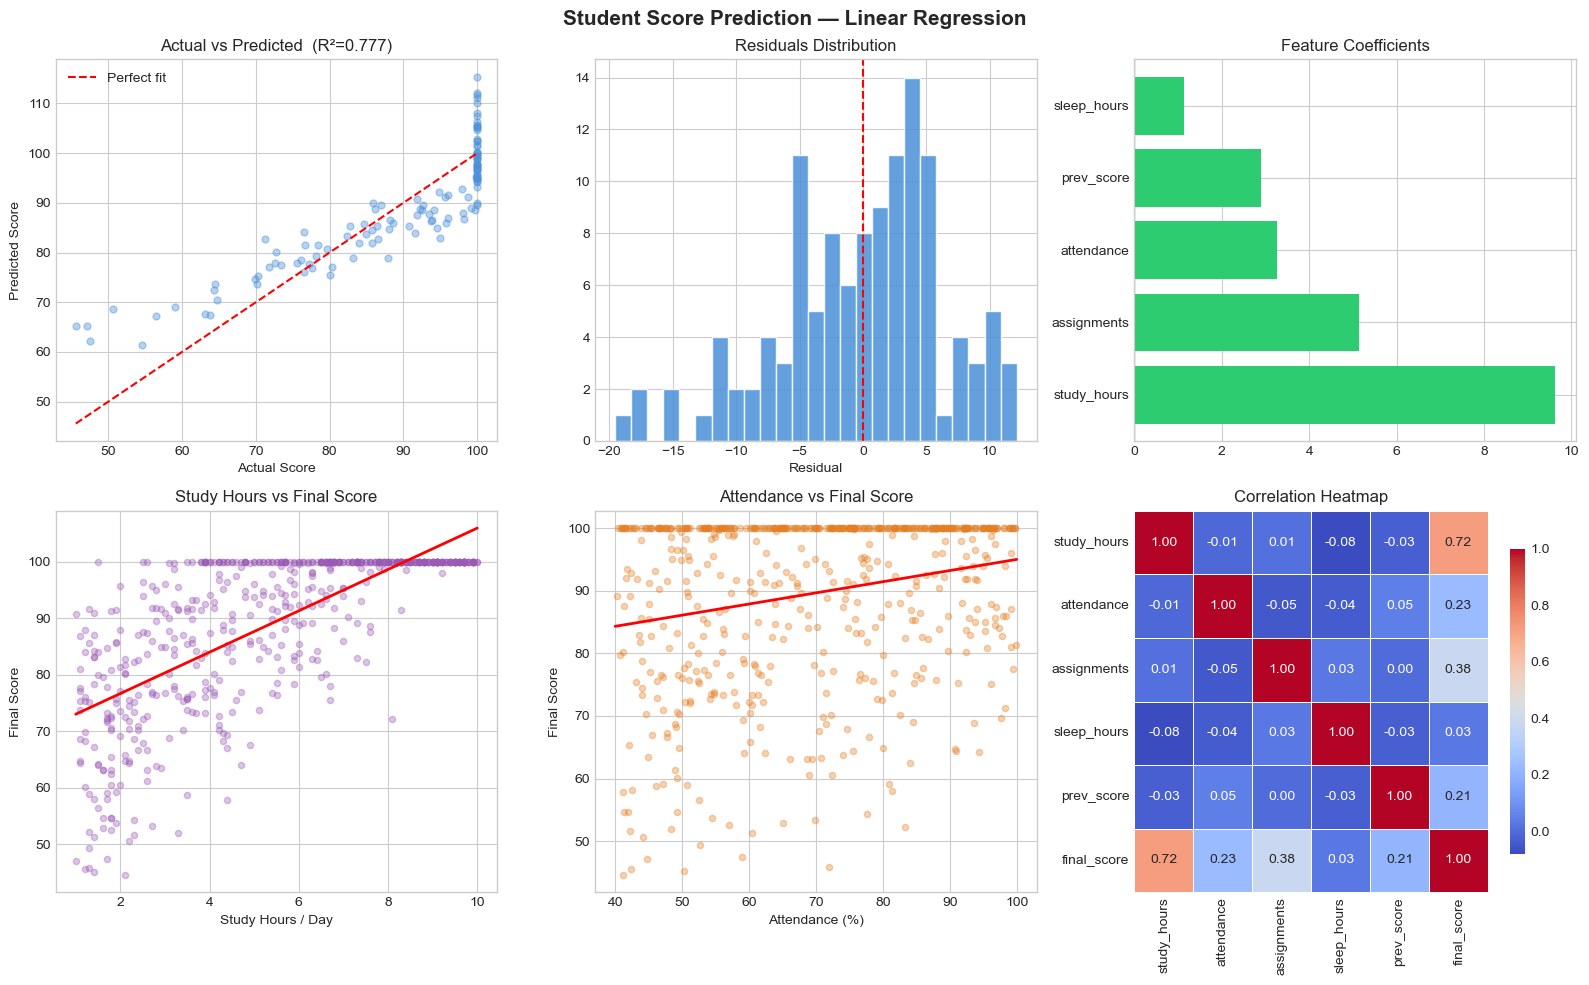


[7] Plot saved as score_prediction.png


In [21]:
#  9. Visualizations 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Student Score Prediction — Linear Regression", fontsize=15, fontweight="bold")

# 9a. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.4, color="#4A90D9", s=25)
mn, mx = y_test.min(), y_test.max()
axes[0, 0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect fit")
axes[0, 0].set_xlabel("Actual Score")
axes[0, 0].set_ylabel("Predicted Score")
axes[0, 0].set_title(f"Actual vs Predicted  (R²={r2:.3f})")
axes[0, 0].legend()

# 9b. Residuals distribution
residuals = y_test - y_pred
axes[0, 1].hist(residuals, bins=25, color="#4A90D9", edgecolor="white", alpha=0.85)
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residuals Distribution")
axes[0, 1].set_xlabel("Residual")

# 9c. Feature coefficients
colors = ["#2ECC71" if c > 0 else "#E74C3C" for c in coef_df["Coefficient"]]
axes[0, 2].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
axes[0, 2].axvline(0, color="black", linewidth=0.8)
axes[0, 2].set_title("Feature Coefficients")

# 9d. Study hours vs Final score
axes[1, 0].scatter(df["study_hours"], df["final_score"], alpha=0.35, color="#9B59B6", s=20)
m, b = np.polyfit(df["study_hours"], df["final_score"], 1)
xs = np.linspace(1, 10, 100)
axes[1, 0].plot(xs, m*xs+b, "r-", linewidth=2)
axes[1, 0].set_xlabel("Study Hours / Day")
axes[1, 0].set_ylabel("Final Score")
axes[1, 0].set_title("Study Hours vs Final Score")

# 9e. Attendance vs Final score
axes[1, 1].scatter(df["attendance"], df["final_score"], alpha=0.35, color="#E67E22", s=20)
m2, b2 = np.polyfit(df["attendance"], df["final_score"], 1)
xs2 = np.linspace(40, 100, 100)
axes[1, 1].plot(xs2, m2*xs2+b2, "r-", linewidth=2)
axes[1, 1].set_xlabel("Attendance (%)")
axes[1, 1].set_ylabel("Final Score")
axes[1, 1].set_title("Attendance vs Final Score")

# 9f. Correlation heatmap
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1, 2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("score_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[7] Plot saved as score_prediction.png")



In [22]:
#  10. Predict for a new student 
print("\n" + "=" * 55)
print("  PREDICT FOR A NEW STUDENT")
print("=" * 55)
new_student = pd.DataFrame([{
    "study_hours": 7.0,
    "attendance":  85.0,
    "assignments": 8,
    "sleep_hours": 7.5,
    "prev_score":  72.0
}])
new_scaled   = scaler.transform(new_student)
prediction   = model.predict(new_scaled)[0]
print("  Input  → study=7h, attendance=85%, assignments=8/10, sleep=7.5h, prev=72")
print(f"  Predicted final score → {prediction:.1f} / 100")
print("=" * 55)
print("\nDone! Check score_prediction.png for the plots.")


  PREDICT FOR A NEW STUDENT
  Input  → study=7h, attendance=85%, assignments=8/10, sleep=7.5h, prev=72
  Predicted final score → 105.3 / 100

Done! Check score_prediction.png for the plots.
